<a href="https://colab.research.google.com/github/getkrishnapavithra-blip/-Customer-Segmentation-Churn-Pattern-Analytics-in-European-Banking/blob/main/google_colab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("Hello, World!")

Hello, World!


In [17]:
import pandas as pd

# Load the Excel file into a pandas DataFrame
try:
    df = pd.read_excel('/content/European_Bank 14 APRIL.xlsx')
    print('Excel file loaded successfully.')
except FileNotFoundError:
    print('Error: The file was not found. Please check the path.')
except Exception as e:
    print(f'An error occurred while loading the file: {e}')

Error: The file was not found. Please check the path.


In [ ]:
# Display the first 5 rows of the DataFrame
print('First 5 rows of the dataset:')
display(df.head())

First 5 rows of the dataset:


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Age Group,NewBalance Segment,Credit Category,New Tenure,Overall Churn Rate
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,30-45,Zero,Medium,New,0.087414
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,30-45,Low,Medium,New,0.087409
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,30-45,High,Medium,Long,0.087389
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,30-45,Zero,Medium,New,0.087398
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,30-45,High,High,New,0.087392


In [ ]:
# Display information about the DataFrame, including data types and non-null values
print('\nDataFrame Information:')
df.info()


DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Year                10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Age Group           10000 non-null  object 
 15  NewBalance Segment  10000 non-

In [ ]:
# Display descriptive statistics for numerical columns
print('\nDescriptive Statistics:')
display(df.describe())


Descriptive Statistics:


,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Overall Churn Rate
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700,0.087698
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769,0.002172
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.071429
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.086686
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.087400
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.087692
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,0.142857


In [ ]:
# Check the distribution of the existing 'NewBalance Segment' column
print('\nDistribution of NewBalance Segment:')
display(df['NewBalance Segment'].value_counts())


Distribution of NewBalance Segment:


,count
NewBalance Segment,
High,4799
Zero,3617
Low,1584


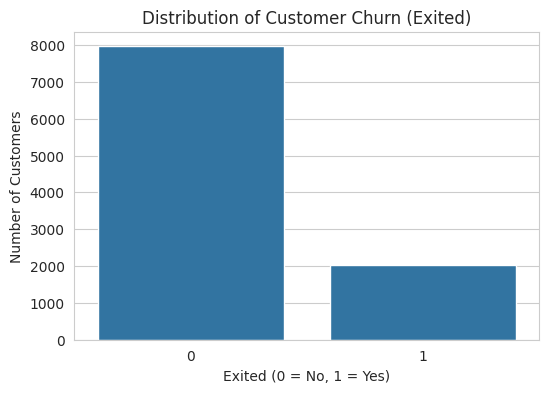

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Plot the distribution of 'Exited'
plt.figure(figsize=(6, 4))
sns.countplot(x='Exited', data=df)
plt.title('Distribution of Customer Churn (Exited)')
plt.xlabel('Exited (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')
plt.show()

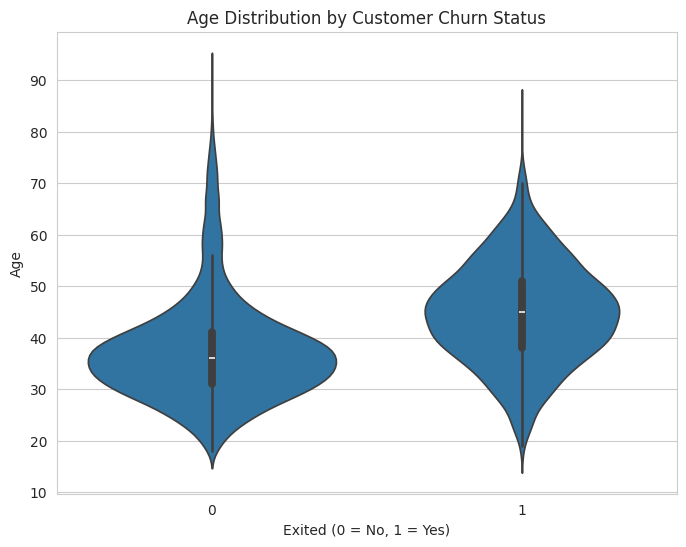

In [ ]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='Exited', y='Age', data=df)
plt.title('Age Distribution by Customer Churn Status')
plt.xlabel('Exited (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()

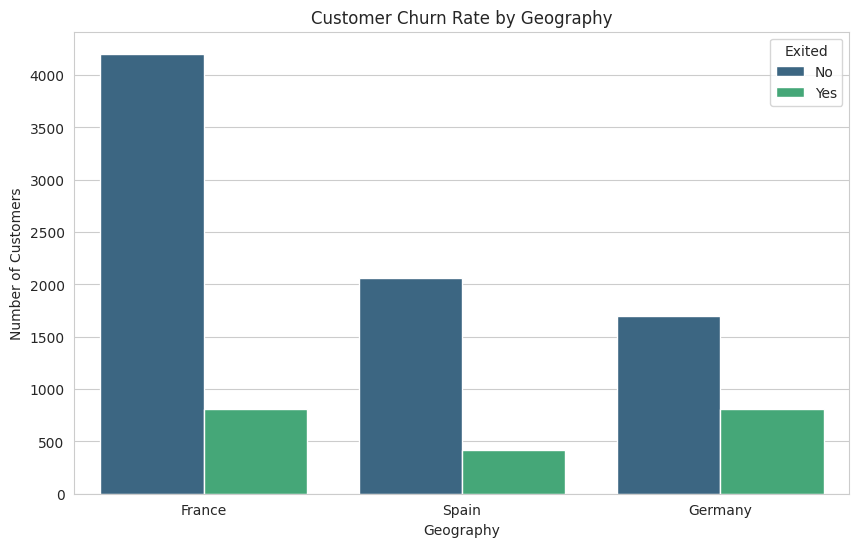

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Geography', hue='Exited', data=df, palette='viridis')
plt.title('Customer Churn Rate by Geography')
plt.xlabel('Geography')
plt.ylabel('Number of Customers')
plt.legend(title='Exited', labels=['No', 'Yes'])
plt.show()

In [ ]:
# Calculate the churn rate by Geography
geography_churn = df.groupby('Geography')['Exited'].value_counts(normalize=True).unstack()
geography_churn['Churn_Percentage'] = geography_churn[1] * 100
display(geography_churn[['Churn_Percentage']].sort_values(by='Churn_Percentage', ascending=False))

Exited,Churn_Percentage
Geography,
Germany,32.443204
Spain,16.673395
France,16.154767


In [ ]:
# Calculate the churn rate by NewBalance Segment
new_balance_churn = df.groupby('NewBalance Segment')['Exited'].value_counts(normalize=True).unstack()
new_balance_churn['Churn_Percentage'] = new_balance_churn[1] * 100
display(new_balance_churn[['Churn_Percentage']].sort_values(by='Churn_Percentage', ascending=False))

Exited,Churn_Percentage
NewBalance Segment,
High,25.234424
Low,20.580808
Zero,13.823611


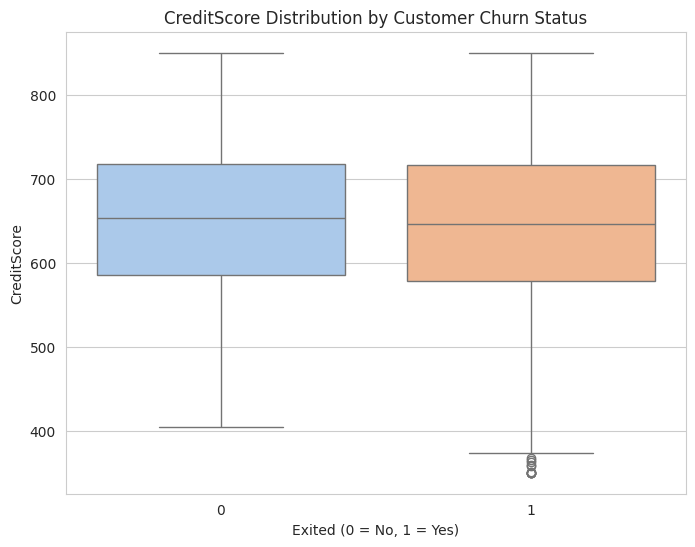

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Exited', y='CreditScore', data=df, hue='Exited', palette='pastel', legend=False)
plt.title('CreditScore Distribution by Customer Churn Status')
plt.xlabel('Exited (0 = No, 1 = Yes)')
plt.ylabel('CreditScore')
plt.show()

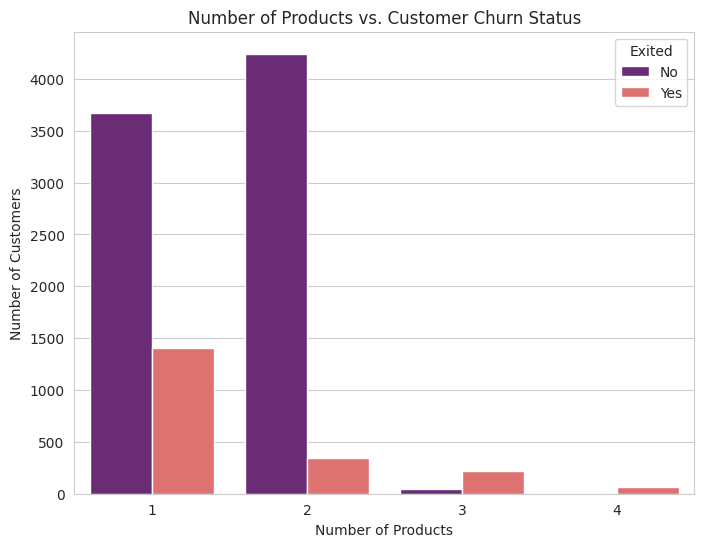

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='NumOfProducts', hue='Exited', data=df, palette='magma')
plt.title('Number of Products vs. Customer Churn Status')
plt.xlabel('Number of Products')
plt.ylabel('Number of Customers')
plt.legend(title='Exited', labels=['No', 'Yes'])
plt.show()

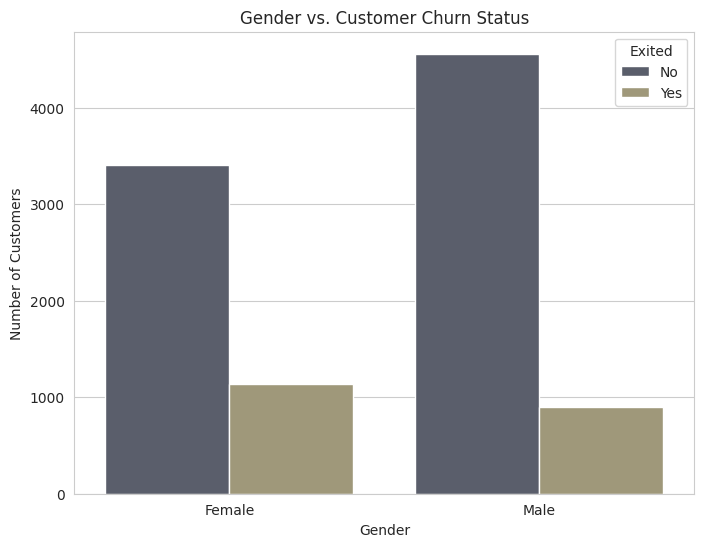

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Gender', hue='Exited', data=df, palette='cividis')
plt.title('Gender vs. Customer Churn Status')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.legend(title='Exited', labels=['No', 'Yes'])
plt.show()

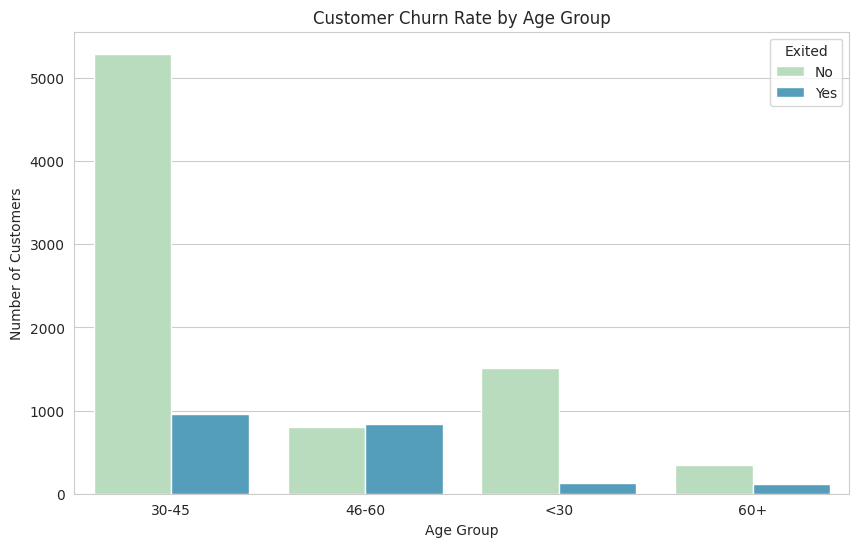

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Age Group', hue='Exited', data=df, palette='GnBu')
plt.title('Customer Churn Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.legend(title='Exited', labels=['No', 'Yes'])
plt.show()

In [ ]:
# Calculate the churn rate by Age Group
age_group_churn = df.groupby('Age Group')['Exited'].value_counts(normalize=True).unstack()
age_group_churn['Churn_Percentage'] = age_group_churn[1] * 100
display(age_group_churn[['Churn_Percentage']].sort_values(by='Churn_Percentage', ascending=False))

Exited,Churn_Percentage
Age Group,
46-60,51.123254
60+,24.784483
30-45,15.300896
<30,7.556368


### Tenure vs. Churn Rate

Let's analyze the relationship between customer tenure and churn rate. This will help us understand if customers who have been with the bank for a shorter or longer period are more likely to churn.

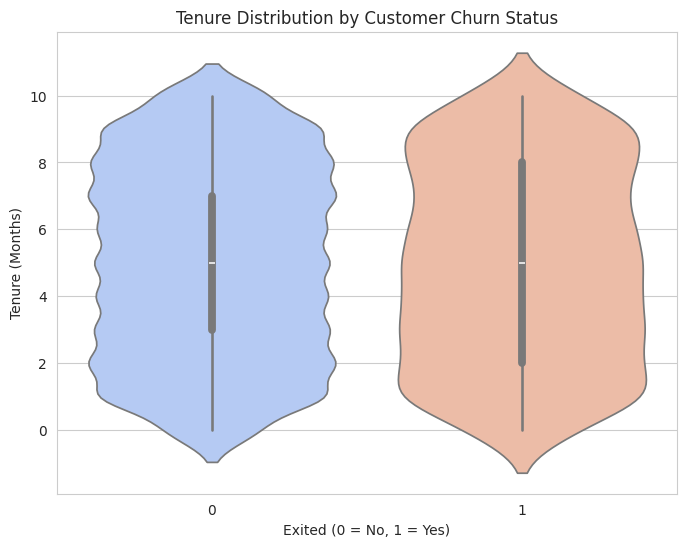

In [ ]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='Exited', y='Tenure', data=df, hue='Exited', palette='coolwarm', legend=False)
plt.title('Tenure Distribution by Customer Churn Status')
plt.xlabel('Exited (0 = No, 1 = Yes)')
plt.ylabel('Tenure (Months)')
plt.show()

In [ ]:
# Calculate the churn rate by Tenure
tenure_churn = df.groupby('Tenure')['Exited'].value_counts(normalize=True).unstack()
tenure_churn['Churn_Percentage'] = tenure_churn[1] * 100
display(tenure_churn[['Churn_Percentage']].sort_values(by='Churn_Percentage', ascending=False))

Exited,Churn_Percentage
Tenure,
0,23.002421
1,22.415459
9,21.646341
3,21.110010
5,20.652174
10,20.612245
4,20.525784
6,20.268873
8,19.219512


### Active Member Status vs. Churn Rate

Let's investigate if a customer's active member status influences their likelihood to churn. Active members are generally more engaged, and it's important to see how this correlates with churn.

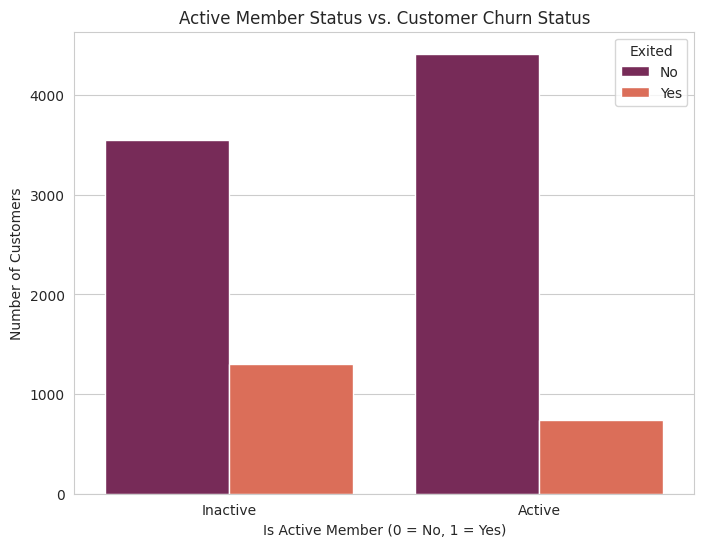

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='IsActiveMember', hue='Exited', data=df, palette='rocket')
plt.title('Active Member Status vs. Customer Churn Status')
plt.xlabel('Is Active Member (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')
plt.legend(title='Exited', labels=['No', 'Yes'])
plt.xticks([0, 1], ['Inactive', 'Active'])
plt.show()

In [ ]:
# Calculate the churn rate by Active Member Status
active_member_churn = df.groupby('IsActiveMember')['Exited'].value_counts(normalize=True).unstack()
active_member_churn['Churn_Percentage'] = active_member_churn[1] * 100
display(active_member_churn[['Churn_Percentage']].sort_values(by='Churn_Percentage', ascending=False))

Exited,Churn_Percentage
IsActiveMember,
0,26.850897
1,14.269074


### Overall Churn Rate

Let's calculate the overall churn rate for all customers in the dataset to get a general understanding of the bank's customer retention performance.

In [ ]:
# Calculate the overall churn rate
overall_churn_rate = df['Exited'].value_counts(normalize=True).get(1, 0) * 100
print(f"Overall Customer Churn Rate: {overall_churn_rate:.2f}%")

Overall Customer Churn Rate: 20.37%


### Create a Web Application with Streamlit

Let's create a simple web application using Streamlit to display the overall churn rate calculated earlier. Streamlit is a great tool for building interactive data apps with Python.

In [6]:
# Install Streamlit
!pip install streamlit -q

In [13]:
import pandas as pd
import streamlit as st

# Load the Excel file into a pandas DataFrame (ensure df is available)
try:
    df = pd.read_excel('/content/European_Bank 14 APRIL.xlsx')
    print('Excel file loaded successfully within app.py creation cell.')
except FileNotFoundError:
    print('Error: The Excel file for Streamlit app was not found. Please check the path.')
    df = pd.DataFrame() # Create an empty DataFrame to avoid errors later
except Exception as e:
    print(f'An error occurred while loading the Excel file for Streamlit app: {e}')
    df = pd.DataFrame() # Create an empty DataFrame to avoid errors later

# Calculate the overall churn rate (ensure it's defined in this cell's scope)
if not df.empty and 'Exited' in df.columns:
    overall_churn_rate = df['Exited'].value_counts(normalize=True).get(1, 0) * 100
else:
    overall_churn_rate = 0.0 # Default if df is empty or 'Exited' column is missing

# Create a Python file for the Streamlit app
streamlit_app_code = f"""
import streamlit as st

st.set_page_config(page_title='Bank Customer Churn Dashboard', layout='wide')

st.title('Bank Customer Churn Analysis')

st.markdown(\"""
This application provides an overview of customer churn based on the provided dataset.
\""")

# Display the overall churn rate in the Streamlit app
app_churn_rate = {overall_churn_rate:.2f}
st.metric(label="Overall Customer Churn Rate", value=f"{{app_churn_rate}}%")

st.subheader("Further Analysis")
st.write("You can extend this dashboard to include interactive charts, filters, and predictions based on the exploratory data analysis and models built in the notebook.")

"""

with open('app.py', 'w') as f:
    f.write(streamlit_app_code)

print('Streamlit app (app.py) created successfully.')

Error: The Excel file for Streamlit app was not found. Please check the path.
Streamlit app (app.py) created successfully.


In [20]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹

⠸⠼⠴⠦Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 2026-04-29 16:31:32.298 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.236.157.200:8501

  Stopping...
^C


### Run the Streamlit Application

To run the Streamlit application:

1.  **Run the cell above** to create the `app.py` file.
2.  **Run the following command** in a new code cell.
3.  Click on the external URL provided by `ngrok` (it might take a moment to appear).

```python
!streamlit run app.py & npx localtunnel --port 8501
```

*(Note: You might need to install `npx localtunnel` first if it's not available, though it's often present in Colab environments.)*